Load the Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

#Exclude Columns Related to Data on the Specific Director (i.e. name, birth/death year).
#Want this to be a tool for new directors/producers trying to break in.
# Keep info on other roles the director played (i.e. producer, actor)
# Note: If new directors were trying to use this tool, they would need to speculate on their Domestic/Worldwide Gross, and the Approval Index
cols_to_exclude = ["genres","director_name","director_professions","director_birthYear","director_deathYear", "Production budget $", "movie_numerOfVotes","movie_averageRating"]

target_cols = ["movie_title","Production budget $"]


x = pd.read_csv("movie_statistic_dataset_processed_buckets.csv",usecols=lambda column: column not in cols_to_exclude)

y = pd.read_csv("movie_statistic_dataset_processed_buckets.csv",usecols=target_cols)
# Convert Year String to Int
x['production_date'] = pd.to_datetime(x['production_date']).dt.year.astype(int)

#Set the title as the index
x = x.set_index('movie_title')
y = y.set_index('movie_title')

# Total entries
print(f'Total Rows: {len(x)}')
#Check for bad runtime (i.e. runtime of 0 or NA) or no budget data
non_zero_runtime = (x['runtime_minutes']!=0).sum()
non_zero_budget= (y['Production budget $']!=0).sum()
print(f'Entries with Non-Zero Runtime: {non_zero_runtime}')
print(f'Entries with Non-Zero Budget: {non_zero_budget}')

# Check the head of the data
#print(f'Head of X: {x.head()}')
#print(f'Head of Y: {y.head()}')

# Describe the Dataset
print(f'Summary: {x.describe()}')

Total Rows: 4380
Entries with Non-Zero Runtime: 4380
Entries with Non-Zero Budget: 4380
Summary:        production_date  runtime_minutes  approval_Index  Domestic gross $  \
count      4380.000000      4380.000000     4380.000000      4.380000e+03   
mean       2003.842237       109.786073        5.032633      5.256385e+07   
std          13.442646        20.375581        1.384890      7.508813e+07   
min        1915.000000        63.000000        0.395487      2.640000e+02   
25%        1999.000000        96.000000        4.178267      8.866234e+06   
50%        2006.000000       106.000000        5.039369      2.832282e+07   
75%        2013.000000       120.000000        5.944203      6.410166e+07   
max        2023.000000       271.000000       10.000000      8.583730e+08   

       Worldwide gross $  genre_Action  genre_Adventure  genre_Comedy  \
count       4.380000e+03   4380.000000      4380.000000   4380.000000   
mean        1.149192e+08      0.276484         0.221005      0.

Split Into Test and Training

In [2]:
from sklearn.model_selection import train_test_split
#Split the data
rand_seed=1
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=rand_seed) 


Regression (w/ Polynomial Features) 

Degree: 1
Degree: 2
Degree: 3
Degree: 4
Degree: 5
MSE Training Results: [708940051889311.0, 524847824076001.9, 305026016760625.25, 18248099752198.086, 3.3393657392559493e-07]
R^2 Training Results: [0.6571636071484035, 0.746188786593877, 0.852492437077838, 0.9911753995577379, 1.0]
MSE Testing Results: [715891955914029.0, 591970208619890.5, 1651964930437276.8, 1.4005999079244418e+21, 4.959648212666034e+21]
R^2 Testing Results: [0.6724105925294489, 0.7291167077936875, 0.24406719721674608, -640908.1346116144, -2269514.95953504]


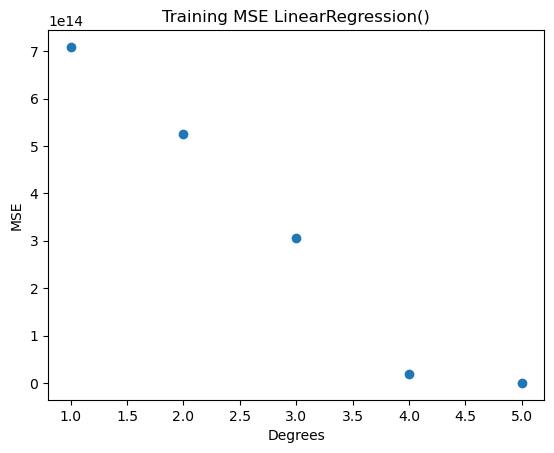

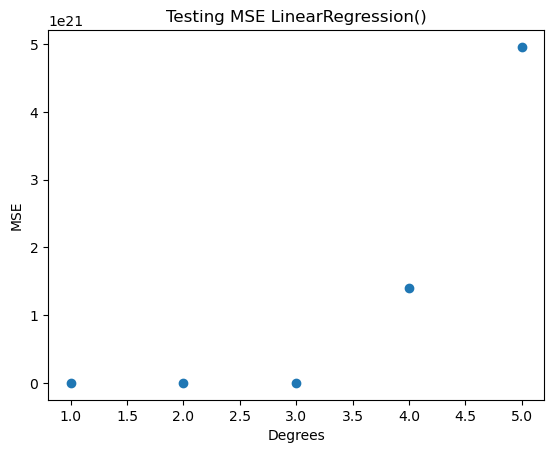

Degree of Min Training MSE: 5
Degree of Min Testing MSE: 2


In [3]:
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.linear_model import LinearRegression 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score




training_mses = []
training_r = []
testing_mses = []
testing_r = []

scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)


def runRegression(training_mses, training_r, testing_mses, testing_r, model,variation):
    for degree in range(1,6):
        print(f'Degree: {degree}')
        poly = PolynomialFeatures(degree=degree, include_bias=False) 
        X_train_poly = poly.fit_transform(X_train_scaled) 
        X_test_poly = poly.transform(X_test_scaled)
        model.fit(X_train_poly, y_train)

        # Predict with the model on the training set and testing set for MSE determination
        Y_train_predict = model.predict(X_train_poly)
        Y_test_predict = model.predict(X_test_poly)

        # MSE Test
        mse_test = mean_squared_error(y_test, Y_test_predict)
        r_test = r2_score(y_test, Y_test_predict)
    
        # Add to array
        testing_mses.append(mse_test)
        testing_r.append(r_test)
        

        #MSE TRAINING
        mse_train = mean_squared_error(y_train, Y_train_predict )
        r_train = r2_score(y_train, Y_train_predict)
        training_mses.append(mse_train)
        training_r.append(r_train)
   
    #MSE Results
    print(f"MSE Training Results: {training_mses}")
    print(f"R^2 Training Results: {training_r}")
    print(f"MSE Testing Results: {testing_mses}")
    print(f"R^2 Testing Results: {testing_r}")
    plt.scatter(range(1,6),training_mses)
    plt.xlabel("Degrees")
    plt.ylabel("MSE")
    plt.title(f"Training MSE {variation}")
    plt.savefig(f"Plots/Training MSE {variation}")
    plt.show()
   
    plt.scatter(range(1,6),testing_mses)
    plt.xlabel("Degrees")
    plt.ylabel("MSE")
    plt.title(f"Testing MSE {variation}")
    plt.savefig(f"Plots/Testing MSE {variation}")
    plt.show()
    # Best Model So Far
    min_training_index = training_mses.index(min(training_mses))
    min_testing_index = testing_mses.index(min(testing_mses))
    print(f'Degree of Min Training MSE: {min_training_index+1}')
    print(f'Degree of Min Testing MSE: {min_testing_index+1}')
    

runRegression(training_mses, training_r, testing_mses, testing_r, model=LinearRegression(),variation="LinearRegression()")
    



RidgeCV 

Degree: 1
Degree: 2
Degree: 3
Degree: 4
Degree: 5
MSE Training Results: [709037536668038.6, 525402511531613.1, 407801396828986.7, 230884462409654.56, 113560347764306.73]
R^2 Training Results: [0.6571164644741987, 0.7459205452299775, 0.8027912804247641, 0.8883465589973962, 0.9450833397058988]
MSE Testing Results: [717302709716966.9, 592640218931564.6, 591194614323035.8, 1159373983969210.8, 7.542998090240771e+16]
R^2 Testing Results: [0.671765037011506, 0.7288101136502736, 0.7294716167629045, 0.46947492103004473, -33.51646934317857]


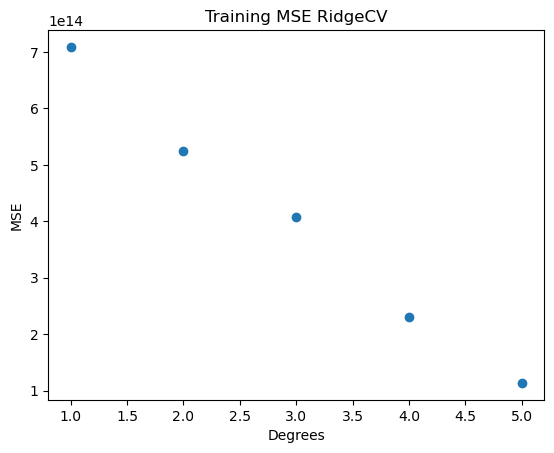

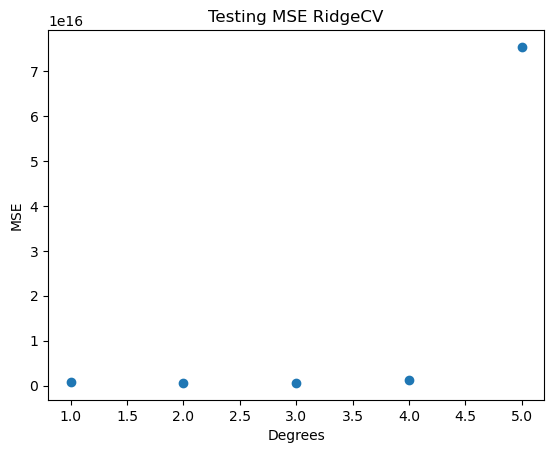

Degree of Min Training MSE: 5
Degree of Min Testing MSE: 3


In [4]:
from sklearn.linear_model import RidgeCV

# RidgeCV Normalization
ridge_training_mses= []
ridge_training_r=[]
ridge_testing_mses=[]
ridge_testing_r=[]
runRegression(ridge_training_mses, ridge_training_r, ridge_testing_mses, ridge_testing_r, model=RidgeCV(alphas = [0.001,0.01,0.1,1,10,100,1000]),variation="RidgeCV")


HuberRegressor

Degree: 1
Degree: 2


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Degree: 3


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Degree: 4


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Degree: 5


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


MSE Training Results: [970218565571469.6, 756400101537931.4, 486578815220603.94, 302831168402456.7, 403178684953837.3]
R^2 Training Results: [0.5308119037544422, 0.6342123968412291, 0.7646953005353956, 0.8535538440218601, 0.8050267781375043]
MSE Testing Results: [1082364408980767.0, 778986643595671.6, 649334423057689.2, 2243039841303533.0, 3.844229838498028e+16]
R^2 Testing Results: [0.5047142065557684, 0.6435387059529626, 0.7028670637483104, -0.02640641017861145, -16.591047986651958]


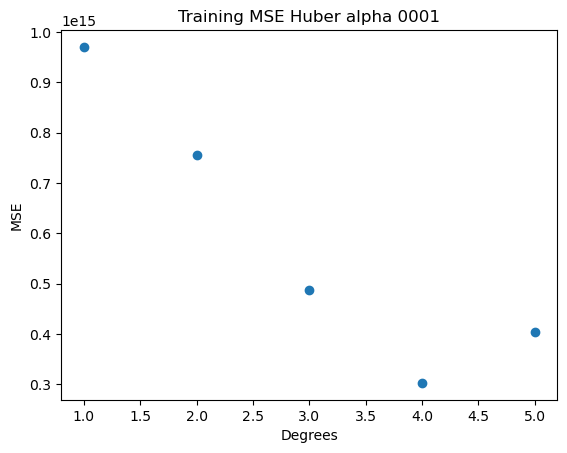

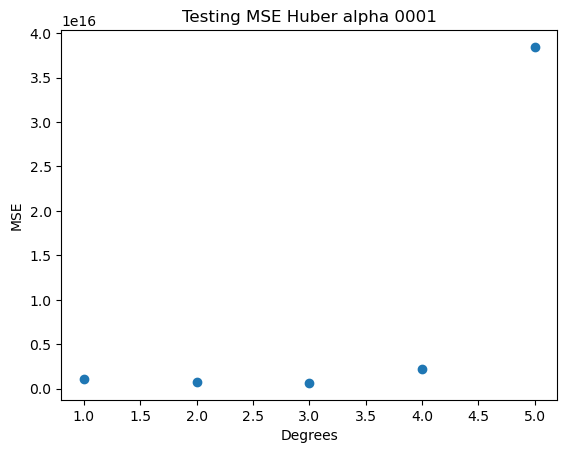

Degree of Min Training MSE: 4
Degree of Min Testing MSE: 3


In [6]:
from sklearn.linear_model import HuberRegressor
huber_training_mses= []
huber_training_r=[]
huber_testing_mses=[]
huber_testing_r=[]
#alpha = 0.0001
runRegression(huber_training_mses, huber_training_r, huber_testing_mses, huber_testing_r, model=HuberRegressor(max_iter=5000),variation="Huber alpha 0001")


Degree: 1
Degree: 2
Degree: 3


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Degree: 4


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Degree: 5


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


MSE Training Results: [1837811891640355.0, 1288206929965299.8, 725516514778014.0, 486902677093070.0, 356840227774858.4]
R^2 Training Results: [0.11125235767026032, 0.3770358778027004, 0.6491473937494621, 0.7645386841390691, 0.827435597426543]
MSE Testing Results: [1978907534257729.5, 1394062362779202.0, 927713212063067.6, 762260997678304.8, 3.2311004257230904e+16]
R^2 Testing Results: [0.09445951832381105, 0.36208242091956455, 0.5754819998580369, 0.6511922972391461, -13.785391359636733]


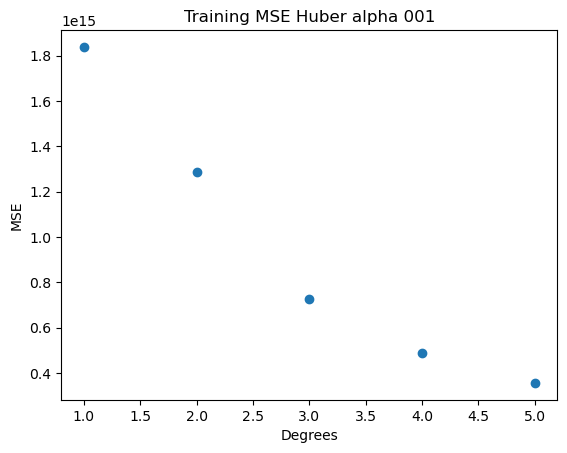

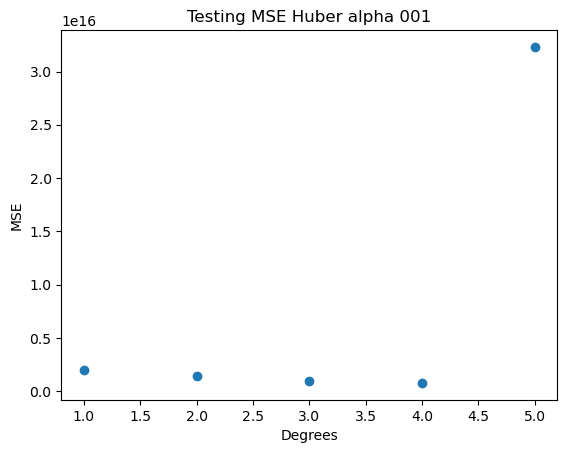

Degree of Min Training MSE: 5
Degree of Min Testing MSE: 4


In [7]:
huber_training_mses2= []
huber_training_r2=[]
huber_testing_mses2=[]
huber_testing_r2=[]
#alpha = 0.001
runRegression(huber_training_mses2, huber_training_r2, huber_testing_mses2, huber_testing_r2, model=HuberRegressor(alpha=0.001,max_iter=5000),variation="Huber alpha 001")

Degree: 1
Degree: 2


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Degree: 3


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Degree: 4


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Degree: 5


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


MSE Training Results: [764003589504354.8, 572111470179600.2, 397350859181949.94, 220097796132401.03, 252299705312598.53]
R^2 Training Results: [0.6305354253109112, 0.7233325550973075, 0.8078450570039286, 0.8935628840555339, 0.8779903594720344]
MSE Testing Results: [811550899233894.2, 610843669396900.9, 960865165206535.6, 2068220900151387.8, 4.6013792022546584e+16]
R^2 Testing Results: [0.6286374277347646, 0.7204802846829326, 0.5603117935202744, 0.05359006536991073, -20.05573437390235]


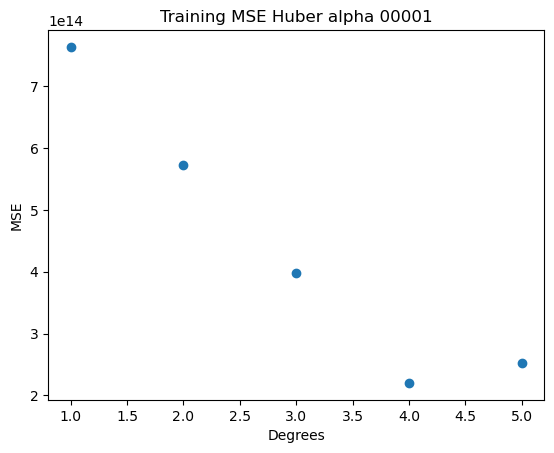

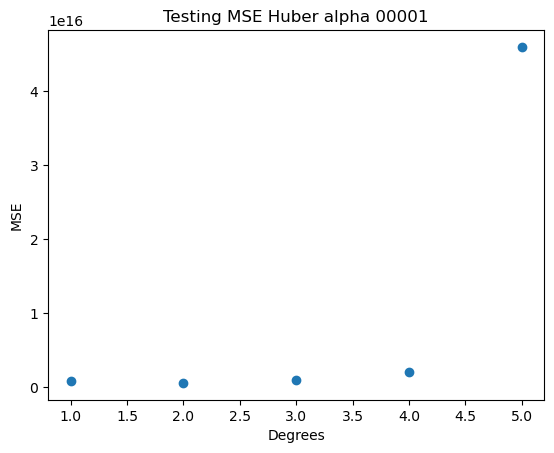

Degree of Min Training MSE: 4
Degree of Min Testing MSE: 2


In [8]:
huber_training_mses3= []
huber_training_r3=[]
huber_testing_mses3=[]
huber_testing_r3=[]
#alpha = 0.00001
runRegression(huber_training_mses3, huber_training_r3, huber_testing_mses3, huber_testing_r3, model=HuberRegressor(alpha=0.00001,max_iter=5000),variation="Huber alpha 00001")

LassoCV

Degree: 1
Degree: 2


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Degree: 3


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.462e+14, tolerance: 5.803e+14
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.098e+14, tolerance: 6.004e+14
  model = cd_fast.enet_coordinate_descent_gram(
/

Degree: 4


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.493e+14, tolerance: 5.803e+14
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.706e+15, tolerance: 5.803e+14
  model = cd_fast.enet_coordinate_descent(
/opt/anacon

Degree: 5


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.561e+16, tolerance: 5.803e+14
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.736e+16, tolerance: 5.803e+14
  model = cd_fast.enet_coordinate_descent(
/opt/anacon

MSE Training Results: [709008023653809.6, 542757880114880.44, 535876255432479.06, 732025293468018.2, 1644550529108592.8]
R^2 Training Results: [0.6571307366757952, 0.7375276607458232, 0.740855546336129, 0.6459998127910953, 0.2047116399204314]
MSE Testing Results: [716986543676978.5, 594983922478943.4, 693545228595023.9, 2879612251882733.5, 2586990832996561.0]
R^2 Testing Results: [0.6719097133762095, 0.7277376439150993, 0.6826363690601995, -0.3176994985713848, -0.1837970619897047]


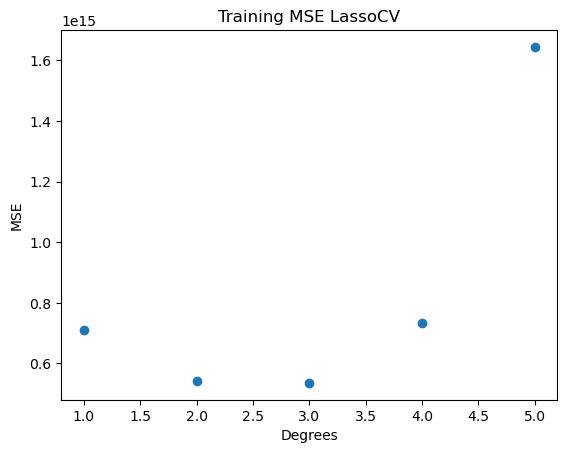

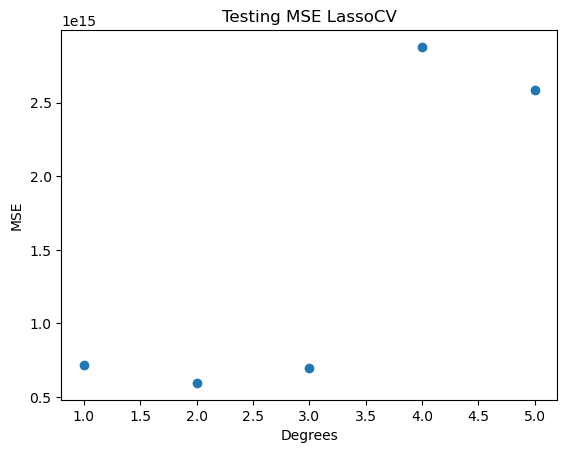

Degree of Min Training MSE: 3
Degree of Min Testing MSE: 2


In [9]:
from sklearn.linear_model import LassoCV
lasso_training_mses = []
lasso_training_r = []
lasso_testing_mses = []
lasso_testing_r = []
runRegression(lasso_training_mses, lasso_training_r, lasso_testing_mses, lasso_testing_r, model=LassoCV(max_iter = 2000, random_state= rand_seed),variation = "LassoCV")

RANSACRegressor

Degree: 1
Degree: 2
Degree: 3
MSE Training Results: [1.9277470519075516e+16, 1925763220338997.8, 1.0958434782607192e+16]
R^2 Training Results: [-8.322393957641331, 0.06871996554882365, -4.299390607367043]
MSE Testing Results: [1.8754511822894876e+16, 1869541972797620.5, 4.170255364407955e+16]
R^2 Testing Results: [-7.581992526536196, 0.14450477889760582, -18.082928262310954]


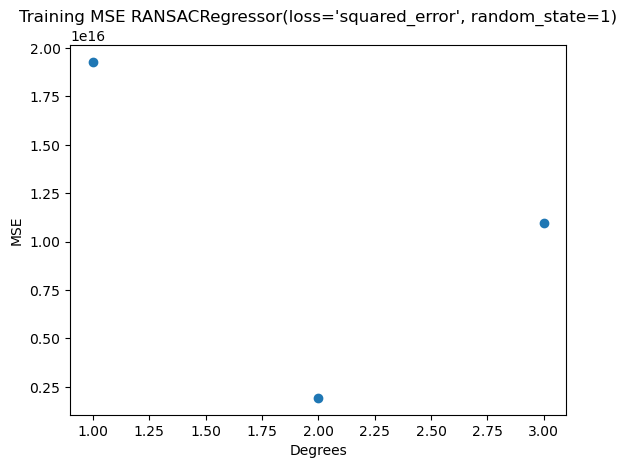

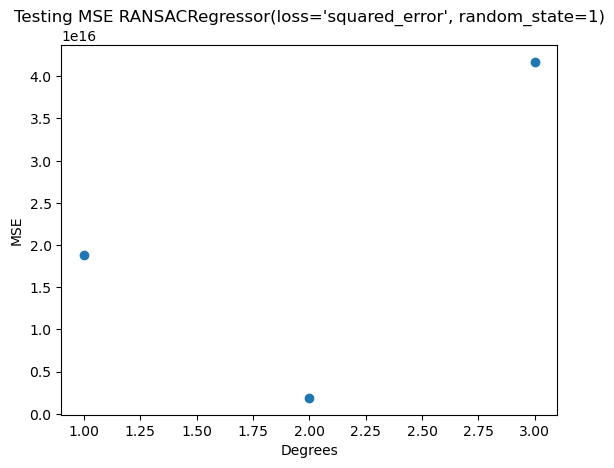

Degree of Min Training MSE: 2
Degree of Min Testing MSE: 2


In [10]:
from sklearn.linear_model import RANSACRegressor
ransac_model = RANSACRegressor(loss='squared_error',random_state=rand_seed)
ransac_training_mses = []
ransac_training_r = []
ransac_testing_mses = []
ransac_testing_r = []
#runRegression(ransac_training_mses, ransac_training_r,ransac_testing_mses,ransac_testing_r, ransac_model)
for degree in range(1,4):
    print(f'Degree: {degree}')
    poly = PolynomialFeatures(degree=degree, include_bias=False) 
    X_train_poly = poly.fit_transform(X_train_scaled) 
    X_test_poly = poly.transform(X_test_scaled)
    ransac_model.fit(X_train_poly, y_train)

    # Predict with the model on the training set and testing set for MSE determination
    Y_train_predict = ransac_model.predict(X_train_poly)
    Y_test_predict = ransac_model.predict(X_test_poly)

    # MSE Test
    mse_test = mean_squared_error(y_test, Y_test_predict)
    r_test = r2_score(y_test, Y_test_predict)
    
    # Add to array
    ransac_testing_mses.append(mse_test)
    ransac_testing_r.append(r_test)
        

    #MSE TRAINING
    mse_train = mean_squared_error(y_train, Y_train_predict )
    r_train = r2_score(y_train, Y_train_predict)
    ransac_training_mses.append(mse_train)
    ransac_training_r.append(r_train)
   
#MSE Results
print(f"MSE Training Results: {ransac_training_mses}")
print(f"R^2 Training Results: {ransac_training_r}")
print(f"MSE Testing Results: {ransac_testing_mses}")
print(f"R^2 Testing Results: {ransac_testing_r}")
plt.scatter(range(1,4),ransac_training_mses)
plt.xlabel("Degrees")
plt.ylabel("MSE")
plt.title(f"Training MSE {ransac_model}")
plt.savefig("Plots/RANSAC Training MSE")
plt.show()
plt.scatter(range(1,4),ransac_testing_mses)
plt.xlabel("Degrees")
plt.ylabel("MSE")
plt.title(f"Testing MSE {ransac_model}")
plt.savefig("Plots/RANSAC Testing MSE")
plt.show()
# Best Model So Far
min_training_index = ransac_training_mses.index(min(ransac_training_mses))
min_testing_index = ransac_testing_mses.index(min(ransac_testing_mses))
print(f'Degree of Min Training MSE: {min_training_index+1}')
print(f'Degree of Min Testing MSE: {min_testing_index+1}')

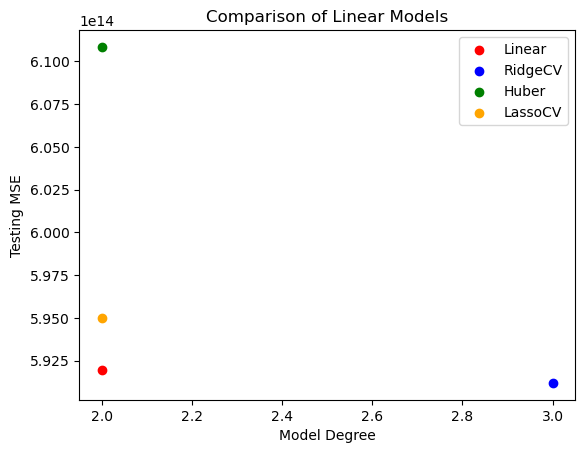

In [11]:
# Figure for Paper: Comparing Linear Regressions
best_mse = [591970208619890.5,591194614323035.8,610843669396900.9,594983922478943.4]
degree = [2,3,2,2]
label = ["Linear","RidgeCV","Huber","LassoCV"]
colors = ['red','blue','green','orange']

for i in range(len(degree)):
    plt.scatter(degree[i],best_mse[i],color=colors[i],label=label[i])

plt.xlabel("Model Degree")
plt.ylabel("Testing MSE")
plt.title("Comparison of Linear Models")
plt.legend()
plt.savefig("Plots/Linear Comparison")

In [15]:
print(f'Min MSE Model: { label[best_mse.index(min(best_mse))]}')

Min MSE Model: RidgeCV


In [16]:
# Describe the Dataset
print(f'Summary: {y.describe()}')

Summary:        Production budget $
count         4.380000e+03
mean          3.869377e+07
std           4.573772e+07
min           5.000000e+04
25%           1.000000e+07
50%           2.300000e+07
75%           5.000000e+07
max           4.600000e+08
